# Анализ приоритизации обращений

Минимальный baseline для задачи.  
Он обучает простую модель только на готовых табличных признаках из `train.csv` / `test.csv` и создает `submission.csv`.

`events.csv` можно использовать для улучшения решения, но в baseline признаки из событий не строятся.

In [666]:
from pathlib import Path

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [667]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [668]:
# Пути к данным.
ROOT = Path(".")
DATA_DIR = ROOT / "data"

TARGET = "target"

# Эти колонки не используем как признаки модели.
ID_COLUMNS = {"lead_id", "user_id"}
TIME_COLUMNS = {"assignment_ts", "assignment_date"}
NON_FEATURE_COLUMNS = ID_COLUMNS | TIME_COLUMNS | {TARGET, "split"}

RANDOM_STATE = 42

## Загрузка данных

Загружаем обучающую выборку, тестовую выборку и события.  
В baseline модель использует только `train.csv` и `test.csv`.

In [669]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

print("train:", train.shape)
print("test:", test.shape)
print("events:", events.shape)

train: (13694, 119)
test: (4306, 118)
events: (254705, 7)


In [670]:
# events.csv не используется в baseline, но его можно исследовать для улучшения решения.
events.head()

,lead_id,user_id,event_ts,event_type,item_price_log,src_slot,ctx_seq
0,lead_00025e9610a0d90d,user_0016636,2026-03-27 06:41:00,chat_open,13.303438,19.0,c02
1,lead_00025e9610a0d90d,user_0016636,2026-03-31 09:10:00,item_view,13.322707,6.0,c06
2,lead_00025e9610a0d90d,user_0016636,2026-04-02 22:04:00,item_view,13.395721,10.0,c06
3,lead_00025e9610a0d90d,user_0016636,2026-04-04 09:19:00,search,13.395955,10.0,c04
4,lead_00025e9610a0d90d,user_0016636,2026-04-07 12:36:00,item_view,13.472769,2.0,c02


## Разведывательный анализ

### Анализ данных в train

In [671]:
train.describe()

,assignment_hour,assignment_weekday,is_weekend,user_active_days_30d,user_age_days,prior_assignments_30d,seller_inventory_count,seller_response_rate_30d,item_price_log,car_age_years,mileage_km_log,item_views_1d,item_views_3d,item_views_7d,item_views_14d,item_views_30d,item_views_90d,item_favorites_1d,item_favorites_3d,item_favorites_7d,item_favorites_14d,item_favorites_30d,item_favorites_90d,detail_expands_1d,detail_expands_3d,detail_expands_7d,detail_expands_14d,detail_expands_30d,detail_expands_90d,photo_swipes_1d,photo_swipes_3d,photo_swipes_7d,photo_swipes_14d,photo_swipes_30d,photo_swipes_90d,seller_page_views_1d,seller_page_views_3d,seller_page_views_7d,seller_page_views_14d,seller_page_views_30d,seller_page_views_90d,search_views_1d,search_views_3d,search_views_7d,search_views_14d,search_views_30d,search_views_90d,query_refinements_1d,query_refinements_3d,query_refinements_7d,query_refinements_14d,query_refinements_30d,query_refinements_90d,similar_item_clicks_1d,similar_item_clicks_3d,similar_item_clicks_7d,similar_item_clicks_14d,similar_item_clicks_30d,similar_item_clicks_90d,saved_search_matches_1d,saved_search_matches_3d,saved_search_matches_7d,saved_search_matches_14d,saved_search_matches_30d,saved_search_matches_90d,user_contacts_1d,user_contacts_3d,user_contacts_7d,user_contacts_14d,user_contacts_30d,user_contacts_90d,chat_opens_1d,chat_opens_3d,chat_opens_7d,chat_opens_14d,chat_opens_30d,chat_opens_90d,call_clicks_1d,call_clicks_3d,call_clicks_7d,call_clicks_14d,call_clicks_30d,call_clicks_90d,leadgen_prev_assigned_1d,leadgen_prev_assigned_3d,leadgen_prev_assigned_7d,leadgen_prev_assigned_14d,leadgen_prev_assigned_30d,leadgen_prev_assigned_90d,leadgen_prev_answered_1d,leadgen_prev_answered_3d,leadgen_prev_answered_7d,leadgen_prev_answered_14d,leadgen_prev_answered_30d,leadgen_prev_answered_90d,leadgen_prev_positive_1d,leadgen_prev_positive_3d,leadgen_prev_positive_7d,leadgen_prev_positive_14d,leadgen_prev_positive_30d,leadgen_prev_positive_90d,active_days_auto_1d,active_days_auto_3d,active_days_auto_7d,active_days_auto_14d,active_days_auto_30d,active_days_auto_90d,target
count,13694.000000,13694.000000,13694.000000,13694.000000,13694.000000,13694.000000,13694.000000,12986.000000,13694.000000,13694.000000,13694.000000,13295.000000,13306.000000,13308.000000,13308.000000,13295.000000,13301.000000,13302.000000,13243.000000,13269.000000,13282.000000,13273.000000,13287.000000,13297.000000,13249.000000,13282.000000,13293.000000,13269.000000,13301.000000,13276.000000,13305.000000,13296.000000,13318.00000,13282.000000,13287.000000,13265.000000,13283.000000,13292.000000,13269.000000,13262.000000,13288.000000,13283.000000,13286.000000,13320.000000,13277.000000,13269.000000,13281.000000,13263.000000,13284.000000,13304.000000,13305.000000,13248.000000,13286.000000,13315.000000,13263.000000,13295.000000,13284.000000,13282.000000,13299.000000,13263.000000,13278.000000,13311.000000,13298.000000,13261.000000,13285.000000,13291.000000,13258.000000,13341.000000,13261.000000,13301.000000,13310.000000,13280.000000,13304.000000,13282.000000,13285.000000,13291.000000,13288.000000,13287.000000,13263.000000,13286.000000,13260.00000,13261.000000,13323.000000,13306.000000,13300.000000,13259.000000,13310.000000,13286.000000,13280.000000,13268.000000,13290.000000,13285.000000,13291.000000,13307.000000,13273.000000,13279.000000,13276.000000,13336.000000,13317.000000,13315.000000,13242.000000,13277.000000,13302.000000,13273.000000,13283.000000,13263.000000,13297.000000,13694.000000
mean,14.477654,2.832408,0.252227,12.383014,415.899664,0.634365,17.466409,0.458104,12.915661,4.615939,10.985782,1.034976,3.116940,7.210400,14.414112,30.805566,92.636869,0.097279,0.290267,0.683699,1.369749,2.910721,8.607887,0.142513,0.430070,1.017317,1.999699,4.202653,12.747087,0.525535,1.575272,3.625827,7.22143,15.481554,46.844434,0.068526,0.195362,0.466552,0.929734,1.972345,6.047712,0.638109,1.915927,4.416366,8.705807,18.675333,56.158422,0.155319,0.465748,1.091627,

In [672]:
train.isna().sum()

lead_id                        0
user_id                        0
assignment_ts                  0
assignment_date                0
lead_source                    0
call_center                    0
region                         0
car_segment                    0
lead_channel                   0
user_tenure_bucket             0
price_bucket                   0
assignment_hour                0
assignment_weekday             0
is_weekend                     0
user_active_days_30d           0
user_age_days                  0
prior_assignments_30d          0
seller_inventory_count         0
seller_response_rate_30d     708
item_price_log                 0
car_age_years                  0
mileage_km_log                 0
item_views_1d                399
item_views_3d                388
item_views_7d                386
item_views_14d               386
item_views_30d               399
item_views_90d               393
item_favorites_1d            392
item_favorites_3d            451
item_favor

In [673]:
events.isna().sum()

lead_id           0
user_id           0
event_ts          0
event_type        0
item_price_log    0
src_slot          0
ctx_seq           0
dtype: int64

In [674]:
test.isna().sum()

lead_id                        0
user_id                        0
assignment_ts                  0
assignment_date                0
lead_source                    0
call_center                    0
region                         0
car_segment                    0
lead_channel                   0
user_tenure_bucket             0
price_bucket                   0
assignment_hour                0
assignment_weekday             0
is_weekend                     0
user_active_days_30d           0
user_age_days                  0
prior_assignments_30d          0
seller_inventory_count         0
seller_response_rate_30d     222
item_price_log                 0
car_age_years                  0
mileage_km_log                 0
item_views_1d                129
item_views_3d                122
item_views_7d                138
item_views_14d               139
item_views_30d               129
item_views_90d               119
item_favorites_1d            119
item_favorites_3d            119
item_favor

In [675]:
train['region'].value_counts(dropna=False)

region
east       2796
west       2770
central    2725
north      2710
south      2693
Name: count, dtype: int64

In [676]:
train['call_center'].value_counts(dropna=False)

call_center
external    7882
voxys       5812
Name: count, dtype: int64

In [677]:
train['car_segment'].value_counts(dropna=False)

car_segment
standard      5780
budget        4713
premium       1909
commercial    1292
Name: count, dtype: int64

In [678]:
train['lead_source'].value_counts(dropna=False)

lead_source
Model    5688
CRM      4839
Perf     3167
Name: count, dtype: int64

In [679]:
def find_monotonicity_violations(df):
    """
    Возвращает строки df, где нарушается неубывание значений
    в столбцах (item_views_1d <= item_views_3d <= ...).
    Пары, где хотя бы одно значение NaN, игнорируются.
    """

    cols = [
        "item_views_1d", "item_views_3d", "item_views_7d",
        "item_views_14d", "item_views_30d", "item_views_90d"
    ]

    violation = pd.Series(False, index=df.index)

    for prev_col, curr_col in zip(cols[:-1], cols[1:]):
        prev = df[prev_col]
        curr = df[curr_col]

        both_valid = prev.notna() & curr.notna()

        violation = violation | (both_valid & (prev > curr))

    return df.loc[violation]

print(len(find_monotonicity_violations(train)) / len(train))
print(len(find_monotonicity_violations(test)) / len(test))

0.23375200817876443
0.24291686019507663


### Проверка на выбросы

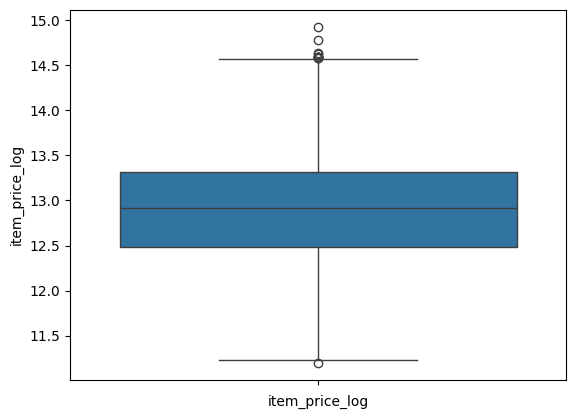

Число и доля выбросов сверху: 11, 0.0008032715057689499
Число и доля выбросов снизу: 1, 7.30246823426318e-05


In [680]:
def draw_boxplot(data=train, feature='item_price_log'):
    sns.boxplot(data[feature])
    plt.xlabel(feature)
    plt.show()

    Q1 = np.percentile(data[feature], 25)
    Q3 = np.percentile(data[feature], 75)
    IQR = Q3 - Q1

    print(f'Число и доля выбросов сверху: {len(data[data[feature] > (Q3 + 1.5 * IQR)])}, {len(data[data[feature] > (Q3 + 1.5 * IQR)]) / len(data)}')
    print(f'Число и доля выбросов снизу: {len(data[data[feature] < (Q1 - 1.5 * IQR)])}, {len(data[data[feature] < (Q1 - 1.5 * IQR)]) / len(data)}')

draw_boxplot(train, 'item_price_log')

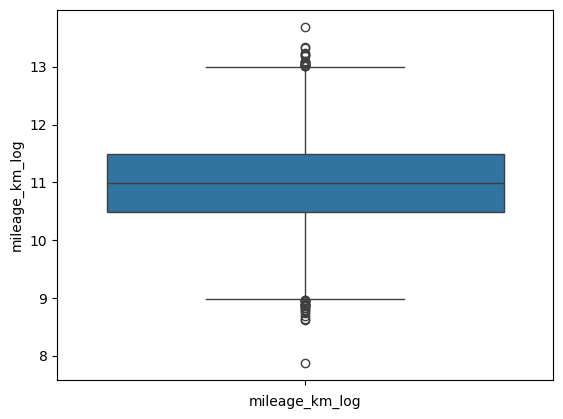

Число и доля выбросов сверху: 19, 0.0013874689645100044
Число и доля выбросов снизу: 22, 0.0016065430115378997


In [681]:
draw_boxplot(train, 'mileage_km_log')

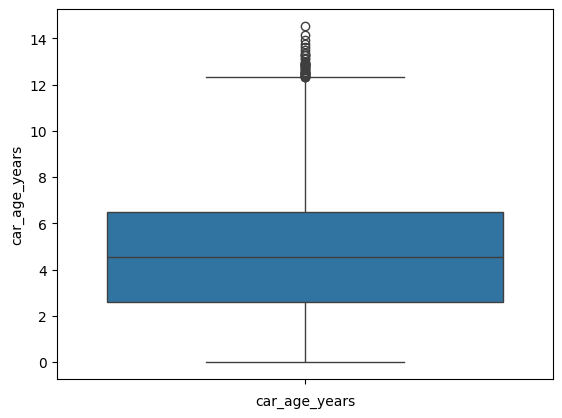

Число и доля выбросов сверху: 42, 0.003067036658390536
Число и доля выбросов снизу: 0, 0.0


In [682]:
draw_boxplot(train, 'car_age_years')

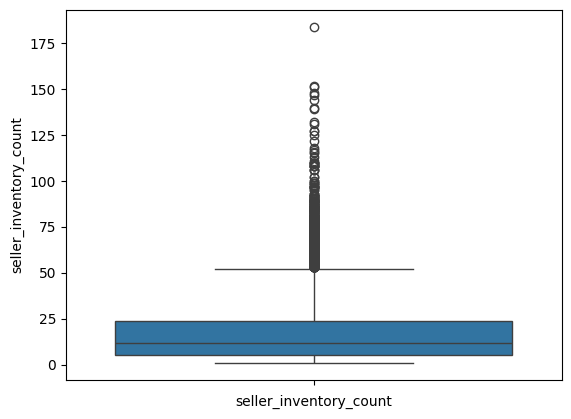

Число и доля выбросов сверху: 740, 0.05403826493354754
Число и доля выбросов снизу: 0, 0.0


In [683]:
draw_boxplot(train, 'seller_inventory_count')

### Анализ данных в events

{1: 45, 2: 109, 3: 186, 4: 339, 5: 556, 6: 731, 7: 960, 8: 1022, 9: 1083, 10: 1180, 11: 1099, 12: 1049, 13: 980, 14: 955, 15: 862, 16: 790, 17: 768, 18: 645, 19: 587, 20: 505, 21: 439, 22: 416, 23: 349, 24: 780, 25: 484, 26: 375, 27: 277, 28: 174, 29: 100, 30: 74, 31: 36, 32: 12, 33: 13, 34: 5, 35: 3}


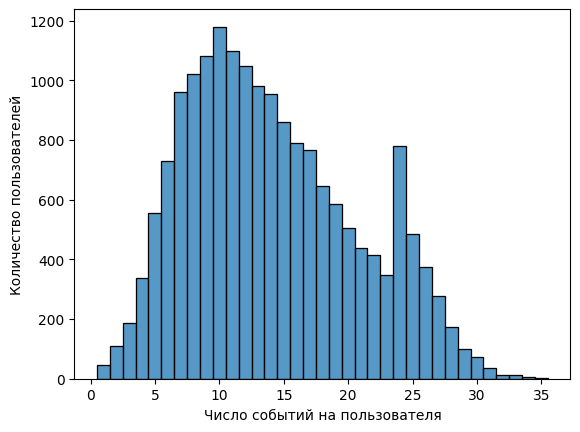

In [684]:
# Сколько событий из events приходится на один user_id из events?
counts = events.groupby('user_id').size()
print(counts.value_counts().sort_index().to_dict())
# print(counts)
sns.histplot(counts, discrete=True)
plt.xlabel('Число событий на пользователя')
plt.ylabel('Количество пользователей')
plt.show()

{21569: 1, 24797: 1, 26333: 1, 61101: 1, 120905: 1}


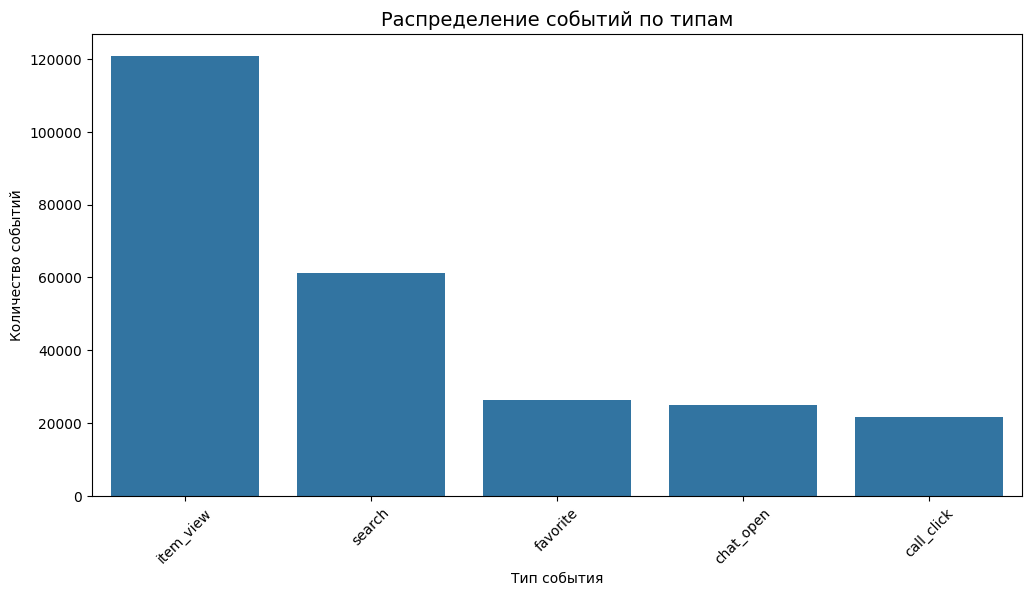

In [685]:
# Какие типы событий есть в event_type?
plt.figure(figsize=(12, 6))
print(events.groupby('event_type').size().value_counts().sort_index().to_dict())
sns.countplot(data=events, x='event_type', order=events['event_type'].value_counts().index)
plt.title('Распределение событий по типам', size=14)
plt.xlabel('Тип события')
plt.ylabel('Количество событий')
plt.xticks(rotation=45)
plt.show()

In [686]:
# У какого процента user_id и lead_id из train.csv есть хотя бы одна запись в events.csv?
def get_overlap_percentage(df, feature):
    event_set = set(events[feature].dropna().unique())
    df_set = set(df[feature].dropna().unique())
    matched_users = df_set.intersection(event_set)
    
    print(len(matched_users))
    return (len(matched_users) / len(df_set)) * 100

print(f"Процент user_id из TRAIN, которые есть в events: {get_overlap_percentage(train, 'user_id'):.3f}%")
print(f"Процент user_id из TEST, которые есть в events:  {get_overlap_percentage(test, 'user_id'):.3f}%\n")

print(f"Процент lead_id из TRAIN, которые есть в events: {get_overlap_percentage(train, 'lead_id'):.3f}%")
print(f"Процент lead_id из TEST, которые есть в events:  {get_overlap_percentage(test, 'lead_id'):.3f}%\n")

13685
Процент user_id из TRAIN, которые есть в events: 99.934%
4303
Процент user_id из TEST, которые есть в events:  99.930%

13685
Процент lead_id из TRAIN, которые есть в events: 99.934%
4303
Процент lead_id из TEST, которые есть в events:  99.930%



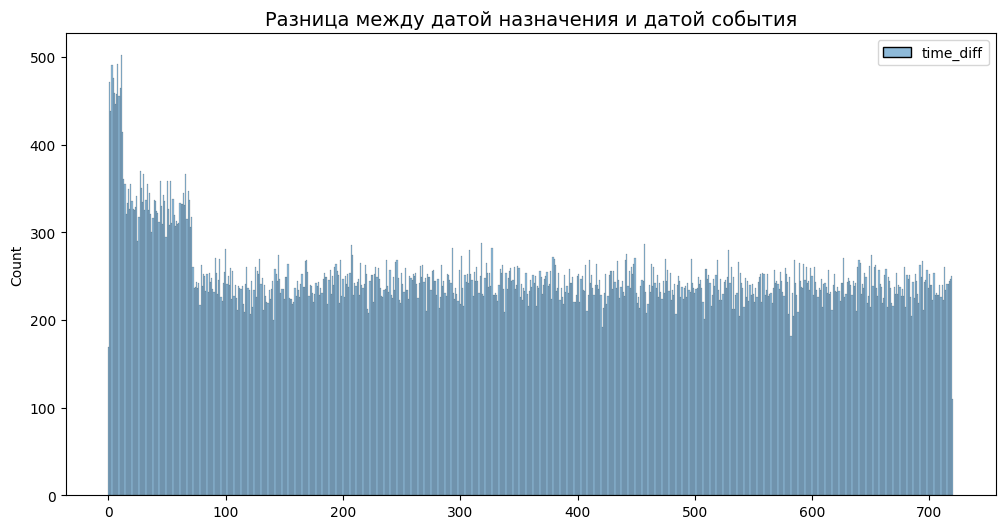

In [687]:
# Посчитаем разницу между event_ts и assignment_ts

def calc_time_diff(train_df, events_df):    
    train = train_df[['lead_id', 'assignment_ts']].copy()
    events = events_df[['lead_id', 'event_ts']].copy()
    
    train['assignment_ts'] = pd.to_datetime(train['assignment_ts'])
    events['event_ts'] = pd.to_datetime(events['event_ts'])
    
    merged_df = pd.merge(train, events, on='lead_id', how='inner')
    
    merged_df['time_diff'] = merged_df['assignment_ts'] - merged_df['event_ts']
    merged_df['time_diff'] = merged_df['time_diff'].dt.total_seconds() / 3600
    
    return merged_df[merged_df['event_ts'] < merged_df['assignment_ts']] # чтобы не было target leakage

plt.figure(figsize=(12, 6))
sns.histplot(data=calc_time_diff(train, events), discrete=True)
plt.title('Разница между датой назначения и датой события', size=14)
plt.show()

In [688]:
# Посчитаем среднее количество событий каждого типа для target=0 и target=1.

def calculate_avg_events_per_target(train_df, events_df):
    event_counts = events_df.groupby(['lead_id', 'event_type']).size().unstack(fill_value=0)
    
    merged_df = train_df.merge(event_counts, on='lead_id', how='inner')

    event_type_cols = event_counts.columns
    merged_df[event_type_cols] = merged_df[event_type_cols].fillna(0)
    
    avg_events = merged_df.groupby('target')[event_type_cols].mean()
    
    return avg_events

calculate_avg_events_per_target(train, events)

,call_click,chat_open,favorite,item_view,search
target,,,,,
0,1.024899,1.191534,1.249816,6.435633,3.312523
1,2.080957,2.338613,2.523407,8.253080,3.854981


In [689]:
# Совпадает ли цена у одного и того же обращения в train и events?

def is_price_equal(train, events):

    events = events.rename(columns={'item_price_log': 'event_price'})
    train = train.rename(columns={'item_price_log': 'train_price'})

    merged = pd.merge(train, events, on='lead_id', how='left')

    merged['is_price_match'] = np.isclose(merged['event_price'], merged['train_price'], equal_nan=True)

    total_leads = len(merged)
    matched_leads = merged['is_price_match'].sum()
    missing_events = merged['event_price'].isna().sum()

    print(f"Всего лидов в train: {total_leads}")
    print(f"Лидов без событий в events: {missing_events}")
    print(f"Совпадает цена: {matched_leads} ({matched_leads / total_leads * 100:.2f}%)")
    print(f"Не совпадает цена: {total_leads - matched_leads - missing_events}")
is_price_equal(train, events) # нет!

Всего лидов в train: 197430
Лидов без событий в events: 9
Совпадает цена: 162 (0.08%)
Не совпадает цена: 197259


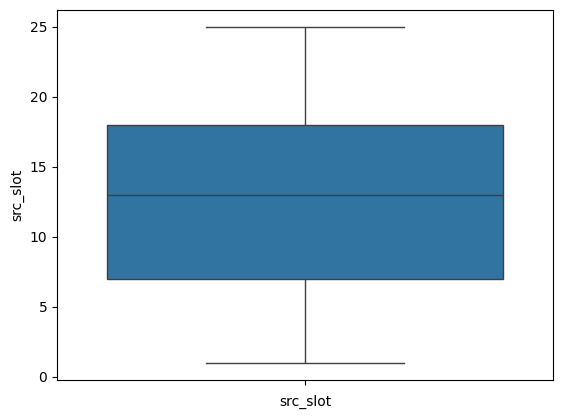

Число и доля выбросов сверху: 0, 0.0
Число и доля выбросов снизу: 0, 0.0


In [690]:
draw_boxplot(events, 'src_slot')

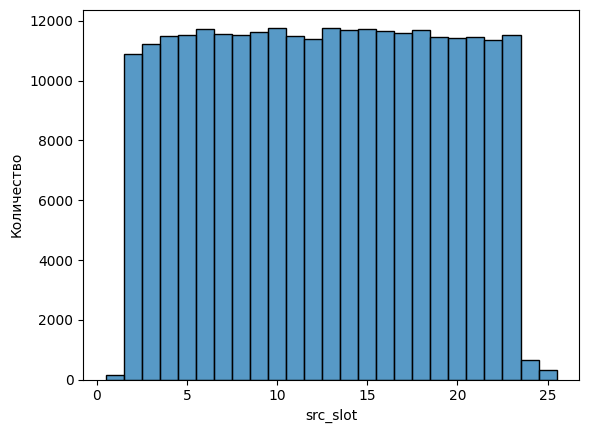

In [691]:
sns.histplot(events['src_slot'], discrete=True)
plt.xlabel('src_slot')
plt.ylabel('Количество')
plt.show()

{'c01': 60728, 'c02': 55370, 'c03': 368, 'c04': 50423, 'c05': 935, 'c06': 50496, 'c07': 930, 'c08': 35455}


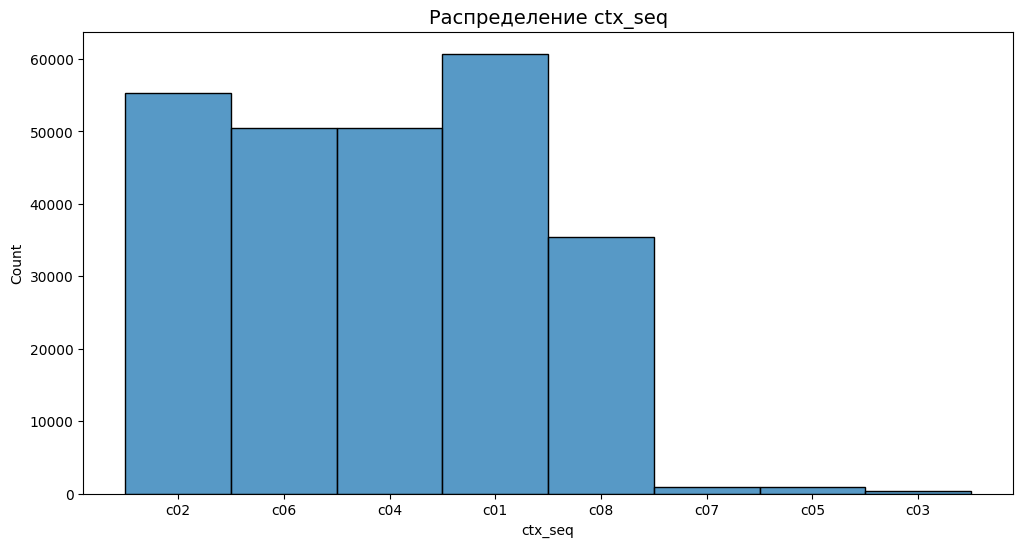

In [692]:
plt.figure(figsize=(12, 6))
print(events['ctx_seq'].value_counts().sort_index().to_dict())
sns.histplot(data=events['ctx_seq'], discrete=True)
plt.title('Распределение ctx_seq', size=14)
plt.show()

### Анализ target и временной структуры

target mean: 0.20746


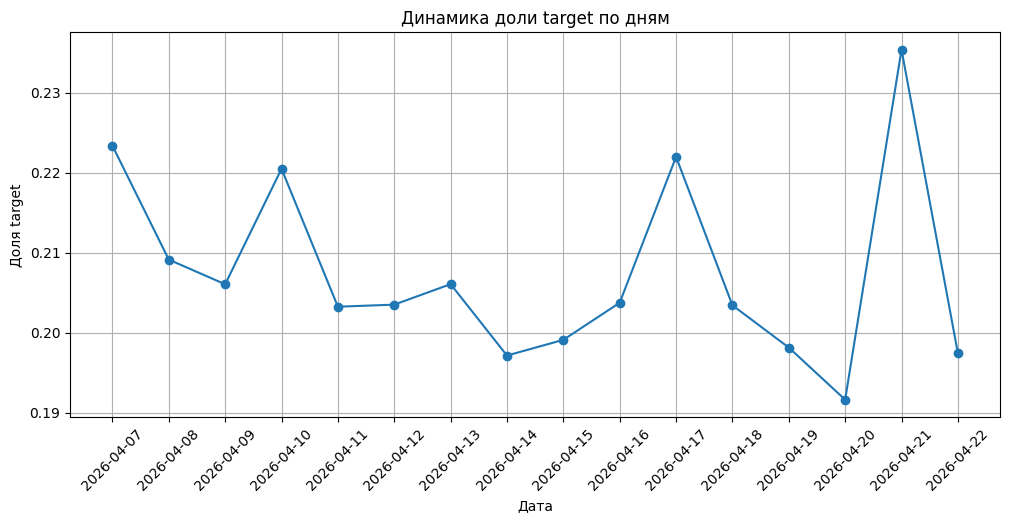

In [693]:
# Доля target глобально и по дням
print("target mean:", f'{train[TARGET].mean():.5f}')

counts = train.groupby('assignment_date')[TARGET].mean()
plt.figure(figsize=(12, 5))
plt.plot(counts.index, counts.values, marker='o', linestyle='-')
plt.xlabel('Дата')
plt.ylabel('Доля target')
plt.title('Динамика доли target по дням')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

assignment_weekday
0.0    1652
1.0    2552
2.0    2592
3.0    1713
4.0    1731
5.0    1736
6.0    1718
dtype: int64


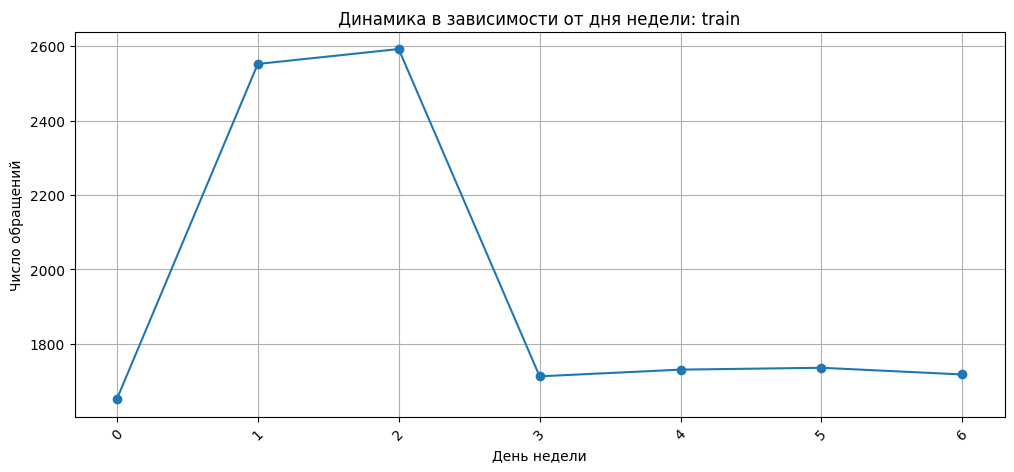

assignment_weekday
0.0    0.198547
1.0    0.218652
2.0    0.201775
3.0    0.204904
4.0    0.221259
5.0    0.203341
6.0    0.200815
Name: target, dtype: float64


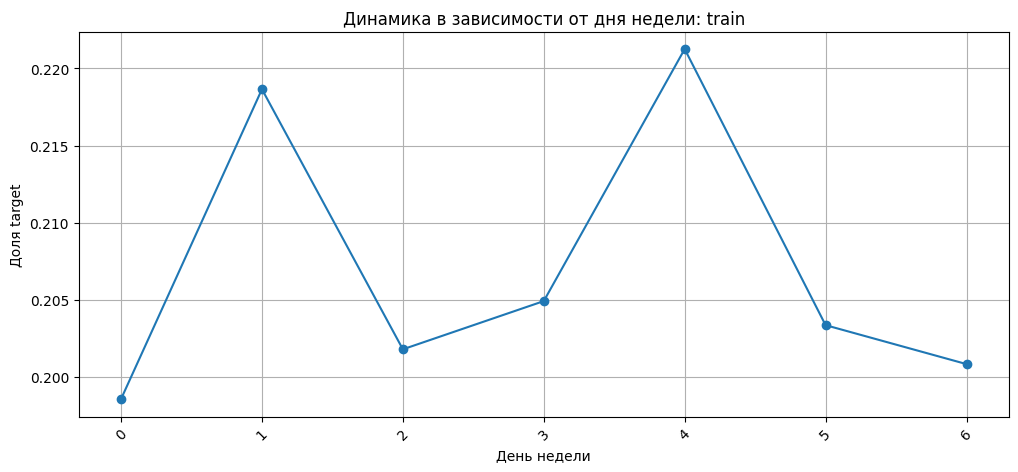

assignment_weekday
0.0    873
3.0    915
4.0    862
5.0    818
6.0    838
dtype: int64


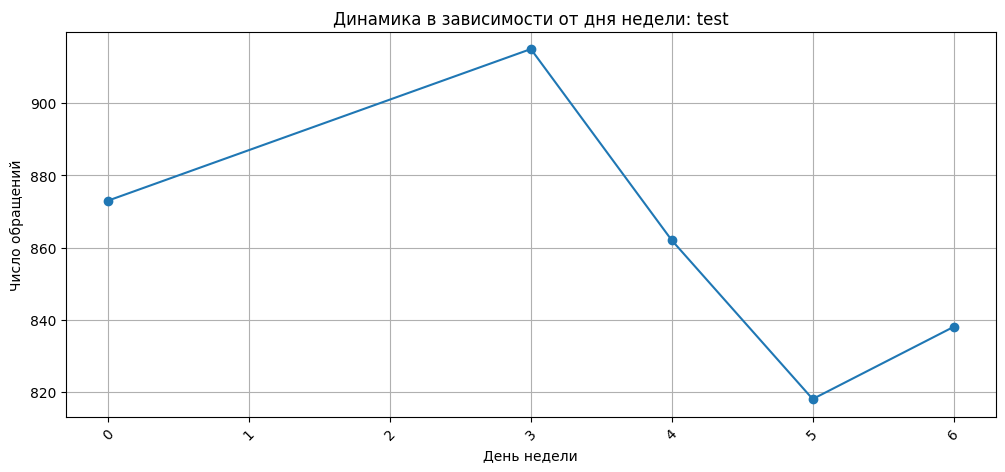

assignment_hour
9.0      311
10.0     621
11.0    1184
12.0    1489
13.0    1877
14.0    1786
15.0    1477
16.0    1524
17.0    1326
18.0     919
19.0     580
20.0     292
21.0     308
dtype: int64


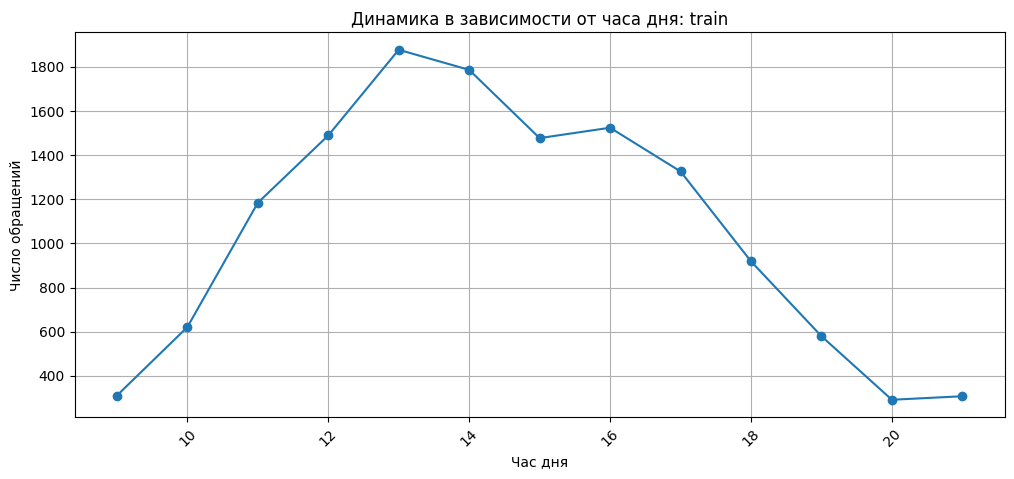

assignment_hour
9.0     0.212219
10.0    0.193237
11.0    0.198480
12.0    0.206179
13.0    0.191795
14.0    0.203247
15.0    0.226134
16.0    0.220472
17.0    0.204374
18.0    0.204570
19.0    0.232759
20.0    0.205479
21.0    0.214286
Name: target, dtype: float64


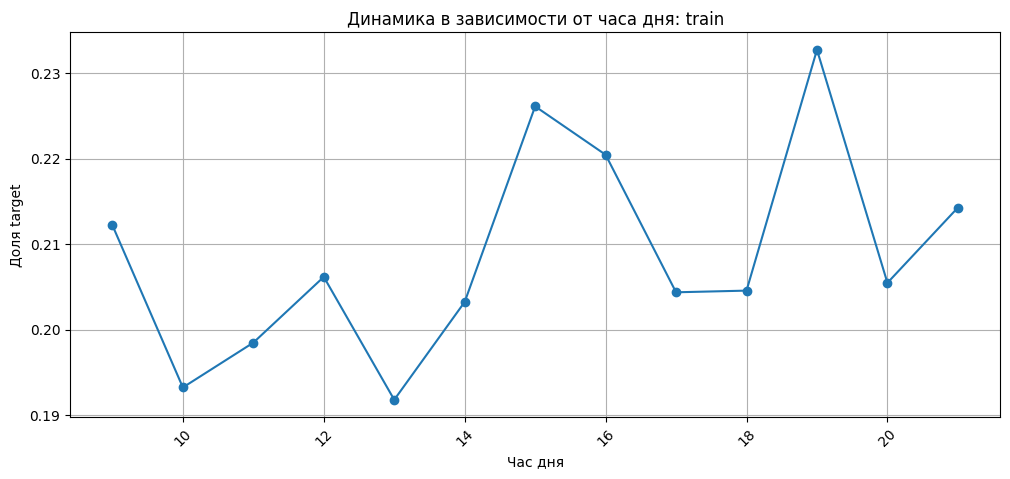

assignment_hour
9.0     119
10.0    176
11.0    386
12.0    480
13.0    610
14.0    515
15.0    489
16.0    519
17.0    355
18.0    257
19.0    201
20.0    102
21.0     97
dtype: int64


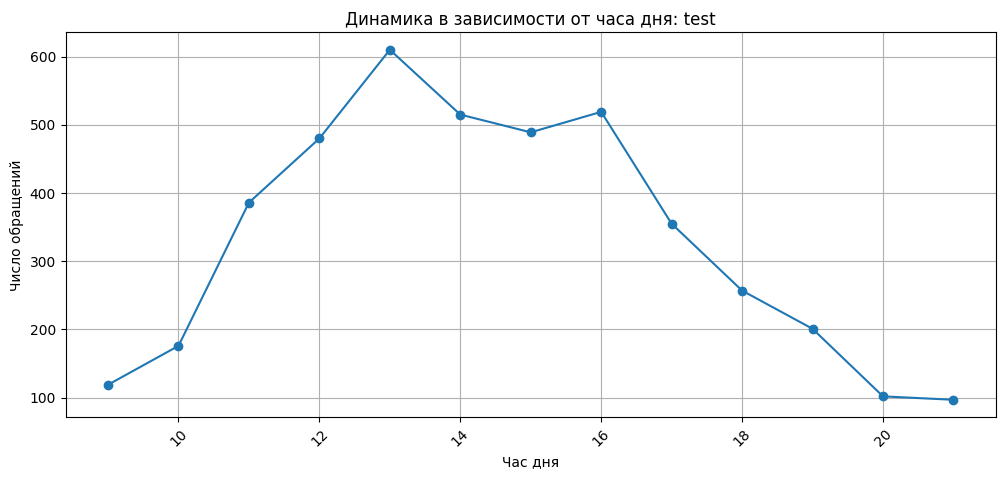

In [694]:
# Распределение обращений по часам и дням недели
def plot_requests(data, mode, data_name, target):
    plt.figure(figsize=(12, 5))

    if mode == 'hour':
        plt.xlabel('Час дня')
        plt.title(f'Динамика в зависимости от часа дня: {data_name}')
    elif mode == 'weekday':
        plt.xlabel('День недели')
        plt.title(f'Динамика в зависимости от дня недели: {data_name}')
    else:
        raise AttributeError('График строится либо по часам (hour), либо по дням недели (day)')

    if target:
        plt.ylabel('Доля target')
        counts = data.groupby(f'assignment_{mode}')[TARGET].mean()
           
    else:
        plt.ylabel('Число обращений')
        counts = data.groupby(f'assignment_{mode}').size()
        
    print(counts)
    plt.plot(counts.index, counts.values, marker='o', linestyle='-')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

plot_requests(train, 'weekday', 'train', False)
plot_requests(train, 'weekday', 'train', True)
plot_requests(test, 'weekday', 'test', False)

plot_requests(train, 'hour', 'train', False)
plot_requests(train, 'hour', 'train', True)
plot_requests(test, 'hour', 'test', False)

In [695]:
# Сравнение временных интервалов
print('Временной интервал train', train['assignment_date'].min(), train['assignment_date'].max())
print('Временной интервал test', test['assignment_date'].min(), test['assignment_date'].max())

Временной интервал train 2026-04-07 2026-04-22
Временной интервал test 2026-04-23 2026-04-27


## Добавление новых признаков

In [696]:
def build_anomaly_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Генерация признаков на основе аномалий во временных окнах.
    """
    out_df = pd.DataFrame(index=df.index)
    
    windows = ['1d', '3d', '7d', '14d', '30d', '90d']
    
    # Проверяем аномалии для просмотров (item_views)
    feature_groups = ['item_views', 'item_favorites', 'detail_expands', 'photo_swipes', 'seller_page_views', 'search_views', 'query_refinements', 'similar_item_clicks', 
                      'saved_search_matches', 'user_contacts', 'chat_opens', 'call_clicks', 'leadgen_prev_assigned', 'leadgen_prev_answered', 
                      'leadgen_prev_positive', 'active_days_auto'
                      ] 
    
    anomaly_matrix = []
    
    for group in feature_groups:
        for i in range(len(windows) - 1):
            w_curr = f"{group}_{windows[i]}"
            w_next = f"{group}_{windows[i+1]}"
            
            if w_curr in df.columns and w_next in df.columns:
                violation = df[w_curr] > df[w_next]
                anomaly_matrix.append(violation)
    
    if anomaly_matrix:
        anomaly_df = pd.concat(anomaly_matrix, axis=1)
        
        out_df['is_anomaly_windows'] = anomaly_df.any(axis=1).astype(int)
        
        out_df['anomaly_windows_count'] = anomaly_df.sum(axis=1)
    else:
        out_df['is_anomaly_windows'] = 0
        out_df['anomaly_windows_count'] = 0
        
    return out_df

In [697]:
def build_events_features(main_df: pd.DataFrame, events_df: pd.DataFrame) -> pd.DataFrame:
    """
    Расчет признаков из events.csv (Recency, Ratios, Context).
    """
    # Подготовка временных срезов во избежание заглядывания в будущее
    train_ts = main_df[['lead_id', 'assignment_ts', 'item_price_log']].copy()
    train_ts['assignment_ts'] = pd.to_datetime(train_ts['assignment_ts'])
    
    events = events_df.copy()
    events['event_ts'] = pd.to_datetime(events['event_ts'])

    merged = pd.merge(events, train_ts, on='lead_id', how='inner', suffixes=('_event', '_main'))
    merged = merged[merged['event_ts'] < merged['assignment_ts']].copy()
    
    # Разница по времени в часах
    merged['time_diff_hours'] = (merged['assignment_ts'] - merged['event_ts']).dt.total_seconds() / 3600.0  

    merged = merged.sort_values(by=['lead_id', 'event_ts'])

    extracted_features = pd.DataFrame(index=main_df['lead_id'])
    
    # Минимальный лаг времени до абсолютно любого события
    extracted_features['min_time_lag'] = merged.groupby('lead_id')['time_diff_hours'].min()
    
    # Лаг времени для конкретных критически важных типов событий
    for etype in ['call_click', 'chat_open', 'favorite']:
        mask = merged['event_type'] == etype
        extracted_features[f'time_since_last_{etype}'] = merged[mask].groupby('lead_id')['time_diff_hours'].min()
    
    # --- БЛОК В: Плотность и пропорции действий (Density & Ratios) ---
    # Общее число событий на лид
    total_counts = merged.groupby('lead_id').size()
    extracted_features['total_events_count'] = total_counts
    
    # Распределяем счетчики по типам событий
    event_type_counts = merged.groupby(['lead_id', 'event_type']).size().unstack(fill_value=0)
    for col in ['call_click', 'chat_open', 'favorite', 'item_view', 'search']:
        if col in event_type_counts.columns:
            extracted_features[f'{col}_count'] = event_type_counts[col]
            # Считаем относительную долю (Ratio) этого действия в поведении пользователя
            extracted_features[f'{col}_ratio'] = event_type_counts[col] / total_counts
        else:
            extracted_features[f'{col}_count'] = 0
            extracted_features[f'{col}_ratio'] = 0.0
            
    # Кастомный Ratio: Поиск против Просмотров
    extracted_features['search_to_view_ratio'] = (
        extracted_features['search_count'] / (extracted_features['item_view_count'] + 1e-5)
    )
    
    # --- БЛОК Г: Контекст (src_slot и ctx_seq) ---
    # Статистика по глубине скролла объявлений
    if 'src_slot' in merged.columns:
        # Приводим к числовому типу на случай, если там строки
        merged['src_slot'] = pd.to_numeric(merged['src_slot'], errors='coerce')
        src_stats = merged.groupby('lead_id')['src_slot'].agg(['mean', 'max', 'last'])
        extracted_features['src_slot_mean'] = src_stats['mean']
        extracted_features['src_slot_max'] = src_stats['max']
        extracted_features['src_slot_last'] = src_stats['last']
        
    # Частота популярных сессий из топ-5, которые вы выделили в EDA
    if 'ctx_seq' in merged.columns:
        top_contexts = ['c01', 'c02', 'c04', 'c06', 'c08']
        ctx_counts = merged.groupby(['lead_id', 'ctx_seq']).size().unstack(fill_value=0)
        for ctx in top_contexts:
            if ctx in ctx_counts.columns:
                extracted_features[f'ctx_{ctx}_count'] = ctx_counts[ctx]
            else:
                extracted_features[f'ctx_{ctx}_count'] = 0

    # Дельты цен
    if 'item_price_log_event' in merged.columns and 'item_price_log_main' in merged.columns:
        price_stats = merged.groupby('lead_id').agg(
            mean_event_price=('item_price_log_event', 'mean'),
            last_event_price=('item_price_log_event', 'last'),
            main_price=('item_price_log_main', 'last')
        )
        extracted_features['price_mismatch_mean_delta'] = price_stats['main_price'] - price_stats['mean_event_price']
        extracted_features['price_mismatch_last_delta'] = price_stats['main_price'] - price_stats['last_event_price']

    return extracted_features.reset_index()

In [698]:
def pipeline_feature_engineering(main_df: pd.DataFrame, events_df: pd.DataFrame) -> pd.DataFrame:
    """
    Полный цикл сборки признаков
    """
    first_block = build_anomaly_features(main_df)    
    second_block = build_events_features(main_df, events_df)    

    full_df = main_df.copy()
    full_df = pd.concat([full_df, first_block], axis=1)
    full_df = pd.merge(full_df, second_block, on='lead_id', how='left')
    
    # # --- СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ (Учитывая LightGBM/CatBoost) ---
    
    # # 1. Заполняем счетчики нулями (если записей в событиях не было, значит действие совершено 0 раз)
    # count_cols = [c for c in full_df.columns if '_count' in c or '_ratio' in c]
    # full_df[count_cols] = full_df[count_cols].fillna(0)
    
    # # 2. Категориальные признаки переводим в string и заполняем 'unknown'
    # # Бустинги (особенно CatBoost) любят явное выделение пропусков в отдельную категорию
    # cat_cols = ['region', 'call_center', 'car_segment', 'lead_source']
    # for col in cat_cols:
    #     if col in full_df.columns:
    #         full_df[col] = full_df[col].astype(str).fillna('unknown')
            
    # # 3. Числовые признаки и временные лаги оставляем как NaN!
    # # LightGBM и CatBoost обработают их нативно без искажения распределений медианами.
    
    return full_df

In [699]:
train = pipeline_feature_engineering(train, events)
test = pipeline_feature_engineering(test, events)

### Анализ корреляции

Также была проанализирована матрица корреляций "всего со всем", но оттуда не удалось взять много информации: коррелируют между собой агрегаты; цена, пробег и возраст машины

/tmp/ipykernel_732782/3783299093.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


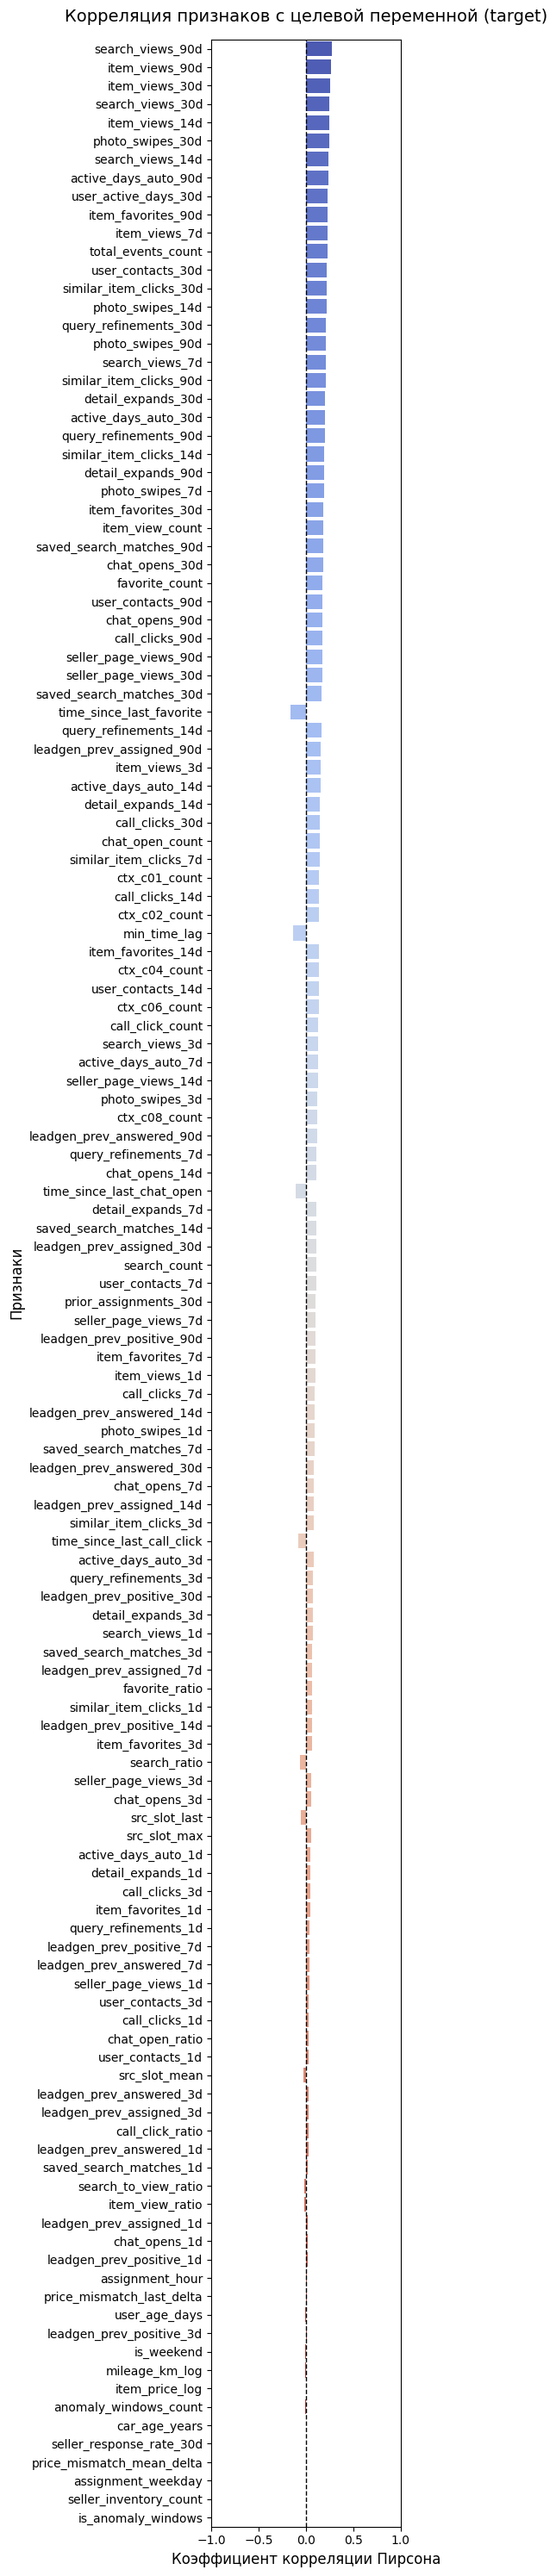

In [700]:
train_numeric = train.select_dtypes(include='number')

corr_with_target = train_numeric.corrwith(train_numeric['target']).drop('target')

corr_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

plt.figure(figsize=(5, 30))
sns.barplot(
    x=corr_sorted.values, 
    y=corr_sorted.index, 
    palette='coolwarm'
)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Корреляция признаков с целевой переменной (target)', fontsize=14, pad=15)
plt.xlabel('Коэффициент корреляции Пирсона', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

## Выбор признаков

Исключаем `lead_id`, `user_id`, timestamps и target.  
Остальные колонки используем как стартовый набор признаков.

In [701]:
feature_columns = [
    column for column in train.columns
    if column not in NON_FEATURE_COLUMNS # and column in test.columns
]

numeric_columns = [
    column for column in feature_columns
    if pd.api.types.is_numeric_dtype(train[column])
]

categorical_columns = [
    column for column in feature_columns
    if column not in numeric_columns
]

print("numeric:", len(numeric_columns))
print("categorical:", len(categorical_columns))
print("total features:", len(feature_columns))

numeric: 135
categorical: 7
total features: 142


## Валидация

Так как тестовая выборка находится позже train по времени, лучше валидироваться на последних датах train.  
Это ближе к реальному сценарию, чем случайный split.

In [702]:
def make_validation_split(train_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Делит train по времени: ранние даты в обучение, поздние даты в валидацию."""
    if "assignment_date" in train_df.columns:
        dates = pd.to_datetime(train_df["assignment_date"]).dt.date
        ordered_dates = sorted(dates.unique())
        cutoff = ordered_dates[int(len(ordered_dates) * 0.8)]

        train_part = train_df[dates < cutoff]
        valid_part = train_df[dates >= cutoff]
        return train_part, valid_part

    # Fallback, если даты нет.
    return train_test_split(
        train_df,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=train_df[TARGET],
    )


train_part, valid_part = make_validation_split(train)

print("train_part:", train_part.shape)
print("valid_part:", valid_part.shape)

train_part: (10272, 147)
valid_part: (3422, 147)


## Модель

Используем простую Logistic Regression:

- числовые признаки: заполнение пропусков медианой и scaling;
- категориальные признаки: заполнение самым частым значением и one-hot encoding;
- `class_weight="balanced"` из-за дисбаланса классов.

In [703]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_columns),
        ("cat", categorical_preprocessor, categorical_columns),
    ],
    remainder="drop",
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

In [704]:
# Обучаемся на ранней части train и проверяем качество на поздней части train.
model.fit(train_part[feature_columns], train_part[TARGET])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['assignment_hour',
                                                   'assignment_weekday',
                                                   'is_weekend',
                                                   'user_active_days_30d',
                                                   'user_age_days',
                                                   'prior_assignments_30d',
                                                   'seller_inventory_count',
                                                   'seller_response_rate_30d',
                                                   'item_price_log',
                                                   'ca...
                                                   'detail_expands_30d',
                                                   'detail_expands_90d',
                                                   'photo_swipes_1d', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['lead_source', 'call_center',
                                                   'region', 'car_segment',
                                                   'lead_channel',
                                                   'user_tenure_bucket',
                                                   'price_bucket'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [705]:
valid_scores = model.predict_proba(valid_part[feature_columns])[:, 1]
valid_ap = average_precision_score(valid_part[TARGET], valid_scores)

print(f"Validation Average Precision: {valid_ap:.5f}")

Validation Average Precision: 0.60660


In [706]:
def compute_daily_ap(df, feature_cols, target_col, model):
    """
    Вычисляет AP для каждого дня и возвращает среднее по дням (daily AP)
    """
    def ap_per_day(group):
        scores = model.predict_proba(group[feature_cols])[:, 1]
        # Если в группе только один класс, AP не имеет смысла – возвращаем NaN
        if group[target_col].nunique() < 2:
            return np.nan
        return average_precision_score(group[target_col], scores)
    
    daily_aps = df.groupby('assignment_date').apply(ap_per_day)
    mean_ap = daily_aps.mean()   # автоматически игнорирует NaN
    return mean_ap, daily_aps

daily_ap_mean, daily_aps = compute_daily_ap(
    df=valid_part,
    feature_cols=feature_columns,
    target_col=TARGET,
    model=model
)

print(f"Validation Daily Average Precision (mean over days): {daily_ap_mean:.5f}")
print(daily_aps)

Validation Daily Average Precision (mean over days): 0.60974
assignment_date
2026-04-19    0.635764
2026-04-20    0.596032
2026-04-21    0.581705
2026-04-22    0.625446
dtype: float64


/tmp/ipykernel_732782/1141699187.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_aps = df.groupby('assignment_date').apply(ap_per_day)


## Submission

Обучаем модель на всем train и строим score для test.  
Файл для отправки должен содержать две колонки: `lead_id` и `score`.

In [707]:
# Финально обучаем модель на всей обучающей выборке.
model.fit(train[feature_columns], train[TARGET])

test_scores = model.predict_proba(test[feature_columns])[:, 1]

submission = pd.DataFrame(
    {
        "lead_id": test["lead_id"].astype(str),
        "score": test_scores,
    }
)

submission.to_csv(ROOT / "submission.csv", index=False)
submission.head()

,lead_id,score
0,lead_97e409eb8f8c8246,0.957649
1,lead_55310edb4489f9e9,0.645469
2,lead_e7f653a2c6a7eee8,0.875002
3,lead_22f8e1cfc487ac20,0.283447
4,lead_48b638b839abfac3,0.282500


In [708]:
# Минимальные проверки формата перед загрузкой.
assert list(submission.columns) == ["lead_id", "score"]
assert len(submission) == len(test)
assert submission["lead_id"].is_unique
assert submission["score"].between(0, 1).all()

print("submission.csv is ready")

submission.csv is ready
